# mimic-video Inference Latency Visualization

Visualizes the latency benchmark results for the mimic-video pipeline.

**Setup:** `pool_mode=none`, `dtype=bf16`, `device=cuda`, `batch_size=1`, `action_steps=10`, `warmup=3`, `repeats=10`

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [9]:
# ── Measured data (pool_mode=none, 10 repeats) ───────────────────────────────
data = {
    "Stage": [
        "1. Video-DiT\nforward",
        "2. Action-DiT\nsingle forward",
        "3. Action-DiT\nODE (10 steps)",
    ],
    "mean_ms":   [90.87, 7.07, 67.47],
    "median_ms": [90.76, 7.09, 67.77],
    "min_ms":    [90.71, 6.77, 63.20],
    "max_ms":    [91.26, 7.18, 71.28],
    "std_ms":    [ 0.21, 0.11,  3.88],
}

total_mean_ms = 158.35

stages   = data["Stage"]
means    = np.array(data["mean_ms"])
stds     = np.array(data["std_ms"])
mins_    = np.array(data["min_ms"])
maxs_    = np.array(data["max_ms"])
medians  = np.array(data["median_ms"])

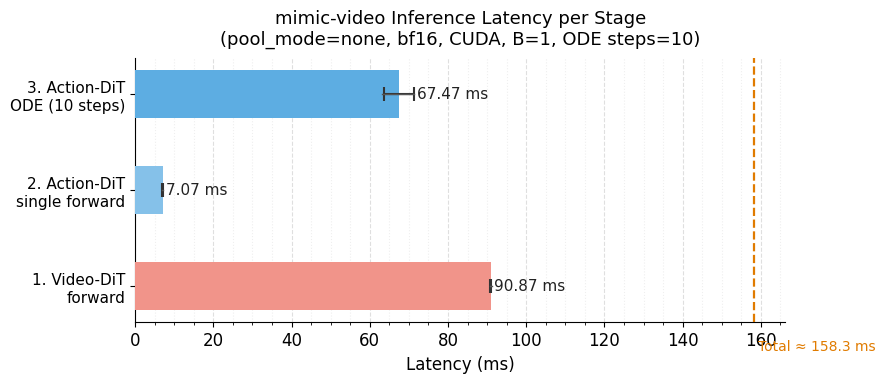

In [10]:
# ── Figure 1: Horizontal bar chart with error bars ───────────────────────────
COLORS = ["#F1948A", "#85C1E9", "#5DADE2"]

fig, ax = plt.subplots(figsize=(9, 4))

y = np.arange(len(stages))
bars = ax.barh(y, means, xerr=stds, color=COLORS, height=0.5,
               error_kw=dict(ecolor='#333', capsize=5, capthick=1.5, lw=1.5),
               zorder=3)

# min/max whiskers
for i, (lo, hi, m) in enumerate(zip(mins_, maxs_, means)):
    ax.plot([lo, hi], [i, i], color='#555', lw=1, zorder=4)

# value labels
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(m + s + 0.8, i, f"{m:.2f} ms", va='center', fontsize=11, color='#222')

ax.set_yticks(y)
ax.set_yticklabels(stages, fontsize=11)
ax.set_xlabel("Latency (ms)", fontsize=12)
ax.set_title("mimic-video Inference Latency per Stage\n"
             r"(pool_mode=none, bf16, CUDA, B=1, ODE steps=10)",
             fontsize=13, pad=10)
ax.xaxis.set_minor_locator(MultipleLocator(5))
ax.grid(axis='x', linestyle='--', alpha=0.4, zorder=0)
ax.grid(axis='x', which='minor', linestyle=':', alpha=0.2, zorder=0)

# total annotation
ax.axvline(total_mean_ms, color='#e07b00', ls='--', lw=1.6, zorder=5)
ax.text(total_mean_ms + 1, -0.55, f"Total ≈ {total_mean_ms:.1f} ms",
        color='#e07b00', fontsize=10, va='top')

plt.tight_layout()
plt.savefig("latency_bar.png", dpi=150, bbox_inches='tight')
plt.show()

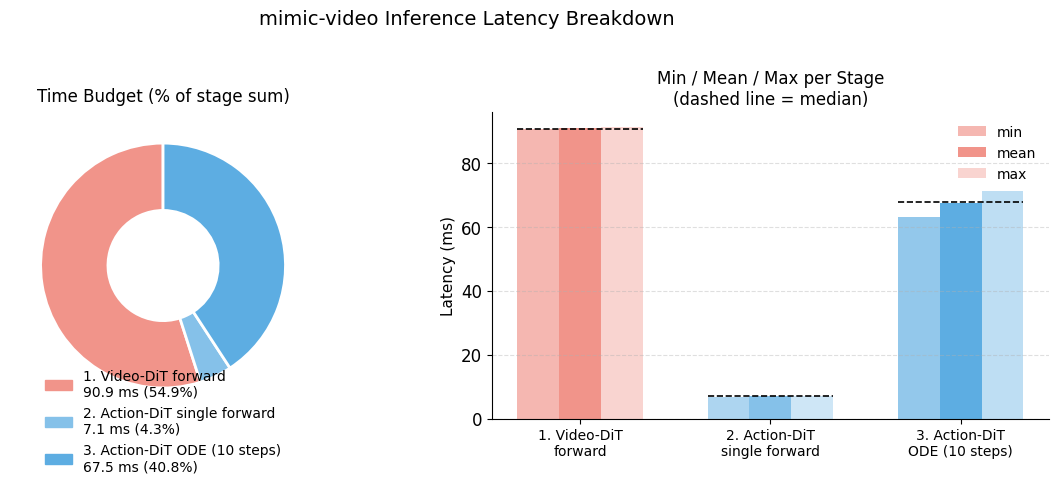

In [11]:
# ── Figure 2: Stacked time-budget pie & breakdown ────────────────────────────
fractions = means / means.sum() * 100
labels_pie = [f"{s.replace(chr(10), ' ')}\n{m:.1f} ms ({f:.1f}%)"
              for s, m, f in zip(stages, means, fractions)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: pie
wedges, texts = axes[0].pie(
    means, labels=None, colors=COLORS,
    startangle=90, wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    pctdistance=0.75,
)
# manual legend
patches = [mpatches.Patch(color=c, label=l) for c, l in zip(COLORS, labels_pie)]
axes[0].legend(handles=patches, loc='lower center', bbox_to_anchor=(0.5, -0.22),
               fontsize=10, frameon=False)
axes[0].set_title("Time Budget (% of stage sum)", fontsize=12, pad=8)

# Right: min/mean/max grouped bars
x = np.arange(len(stages))
w = 0.22
axes[1].bar(x - w, mins_,   width=w, label='min',    color=[c + 'aa' for c in ['#F1948A','#85C1E9','#5DADE2']])
axes[1].bar(x,     means,   width=w, label='mean',   color=COLORS)
axes[1].bar(x + w, maxs_,   width=w, label='max',    color=[c + '66' for c in ['#F1948A','#85C1E9','#5DADE2']])

# median ticks
for xi, med in zip(x, medians):
    axes[1].plot([xi - w*1.5, xi + w*1.5], [med, med], 'k--', lw=1.2, zorder=5)

axes[1].set_xticks(x)
axes[1].set_xticklabels(stages, fontsize=10)
axes[1].set_ylabel("Latency (ms)", fontsize=11)
axes[1].set_title("Min / Mean / Max per Stage\n(dashed line = median)", fontsize=12)
axes[1].legend(fontsize=10, frameon=False)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle("mimic-video Inference Latency Breakdown", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("latency_breakdown.png", dpi=150, bbox_inches='tight')
plt.show()

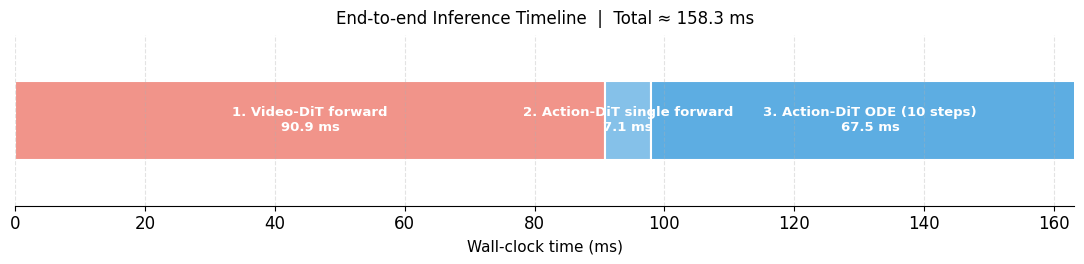

In [12]:
# ── Figure 3: Gantt-style sequential timeline ─────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 2.8))

starts = np.concatenate([[0], np.cumsum(means)[:-1]])

for i, (s, m, c, lbl) in enumerate(zip(starts, means, COLORS, stages)):
    ax.barh(0, m, left=s, color=c, height=0.55, edgecolor='white', linewidth=1.5)
    center = s + m / 2
    ax.text(center, 0, f"{lbl.replace(chr(10), ' ')}\n{m:.1f} ms",
            ha='center', va='center', fontsize=9.5, color='white', fontweight='bold')

ax.set_xlim(0, total_mean_ms * 1.03)
ax.set_ylim(-0.6, 0.6)
ax.set_yticks([])
ax.set_xlabel("Wall-clock time (ms)", fontsize=11)
ax.set_title(f"End-to-end Inference Timeline  |  Total ≈ {total_mean_ms:.1f} ms",
             fontsize=12, pad=8)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.35)

plt.tight_layout()
plt.savefig("latency_timeline.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import torch
t5 = torch.load('/home/qiang/projects/world_action_models/DIT4DIT/precomputed/libero_object/t5_embeddings.pt', weights_only=True)
  # 比较 mean-pooled T5 的余弦相似度
means = {k: v.squeeze(0).mean(0) for k, v in t5.items()}  # {0: [1024], 1: [1024], ...}

import torch.nn.functional as F
for i in range(10):
      for j in range(i+1, 10):
          sim = F.cosine_similarity(means[i].unsqueeze(0), means[j].unsqueeze(0)).item()
          print(f"task {i} vs {j}: sim={sim:.4f}")


IndentationError: unexpected indent (1359743220.py, line 2)